# SmartTriage: Duplicate Detection Threshold Calibrator

This notebook analyzes historical issue data (or synthetic data) to calibrate the optimal cosine similarity threshold for identifying duplicate issues. Finding the exact right threshold ensures the bot isn't too aggressive (closing valid issues) or too passive (missing obvious duplicates).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, f1_score

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 1. Load Data
In a real environment, you would load your historical issues and generate embeddings using `app.ml.embedder`. For this notebook, we simulate similarity scores between pairs of issues.

In [2]:
# Simulating a dataset of issue pairs and their cosine similarities
np.random.seed(42)

# True duplicates usually have higher similarity scores (mean 0.88, std 0.05)
true_duplicates = np.random.normal(0.88, 0.05, 500)
true_duplicates = np.clip(true_duplicates, 0.5, 1.0)

# Non-duplicates usually have lower similarity scores (mean 0.45, std 0.15)
non_duplicates = np.random.normal(0.45, 0.15, 2000)
non_duplicates = np.clip(non_duplicates, 0.0, 1.0)

# Create DataFrame
df_dup = pd.DataFrame({'similarity': true_duplicates, 'is_duplicate': 1})
df_non = pd.DataFrame({'similarity': non_duplicates, 'is_duplicate': 0})
df = pd.concat([df_dup, df_non]).sample(frac=1).reset_index(drop=True)

df.head()

,similarity,is_duplicate
0,0.187720,0
1,0.523378,0
2,0.927700,1
3,0.921103,1
4,0.568594,0


### 2. Visualize Similarity Distributions
This plot helps us visually see where the separation between "duplicates" and "unrelated issues" occurs.

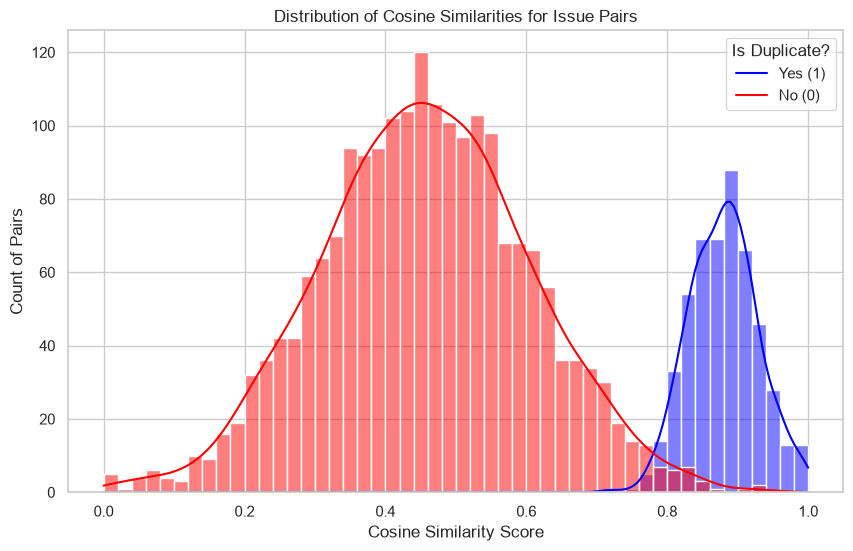

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='similarity', hue='is_duplicate', kde=True, bins=50, palette=['red', 'blue'])
plt.title('Distribution of Cosine Similarities for Issue Pairs')
plt.xlabel('Cosine Similarity Score')
plt.ylabel('Count of Pairs')
plt.legend(title='Is Duplicate?', labels=['Yes (1)', 'No (0)'])
plt.show()

### 3. Precision-Recall Curve & Finding Optimal Threshold
We calculate the F1-Score for every possible threshold to find the mathematical 'sweet spot' that balances Precision (not closing wrong issues) and Recall (catching actual duplicates).

In [4]:
y_true = df['is_duplicate']
y_scores = df['similarity']

precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

# Calculate F1 scores for each threshold
# Note: thresholds array is 1 element shorter than precision/recall arrays
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)

# Find optimal threshold (Highest F1 Score)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"F1 Score at Optimal: {optimal_f1:.4f}")
print(f"Precision at Optimal: {precision[optimal_idx]:.4f}")
print(f"Recall at Optimal: {recall[optimal_idx]:.4f}")

Optimal Threshold: 0.7766
F1 Score at Optimal: 0.9697
Precision at Optimal: 0.9484
Recall at Optimal: 0.9920


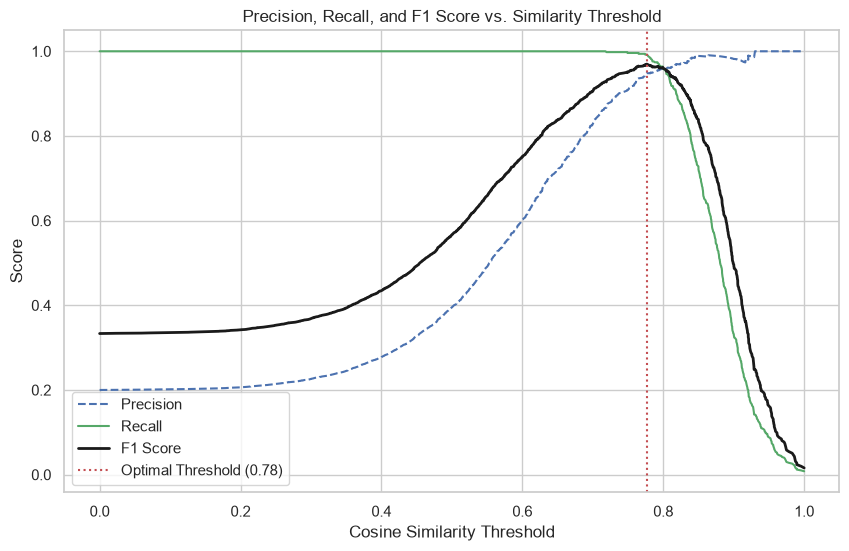

In [5]:
# Plot the tradeoff
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], 'b--', label='Precision')
plt.plot(thresholds, recall[:-1], 'g-', label='Recall')
plt.plot(thresholds, f1_scores, 'k-', linewidth=2, label='F1 Score')

plt.axvline(x=optimal_threshold, color='r', linestyle=':', label=f'Optimal Threshold ({optimal_threshold:.2f})')

plt.title('Precision, Recall, and F1 Score vs. Similarity Threshold')
plt.xlabel('Cosine Similarity Threshold')
plt.ylabel('Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()